In [39]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import pandas as pd
import numpy as np
import streamlit as st
import matplotlib
matplotlib.use('TkAgg')   # or 'Qt5Agg' if you have it installed
import matplotlib.pyplot as plt

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

import joblib

## Load Dataset

In [41]:
df = pd.read_csv("heart.csv")

### Check Data set

In [42]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Dataset Shape

In [43]:
df.shape

(918, 12)

### Dataset Information

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Statistics

In [45]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Data Cleaning

### Missing Values

In [46]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### Duplicate Records

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.drop_duplicates(inplace=True)

## Exploratory Data Analysis

### Target Distribution

<Axes: xlabel='HeartDisease', ylabel='count'>

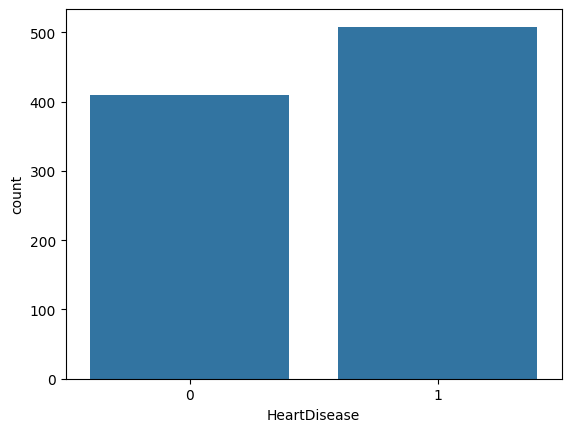

In [49]:
sns.countplot(x='HeartDisease', data=df)


### Age Distribution

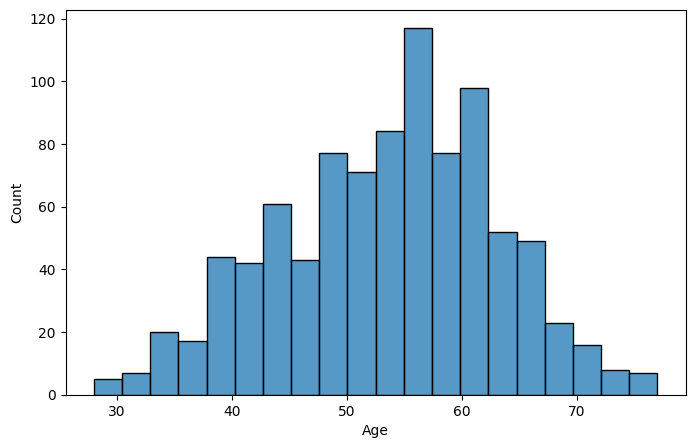

In [50]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20,)
plt.show()

### Boxplots

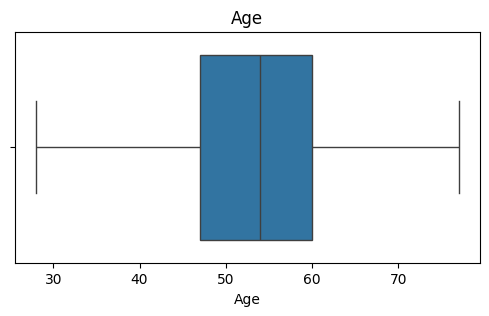

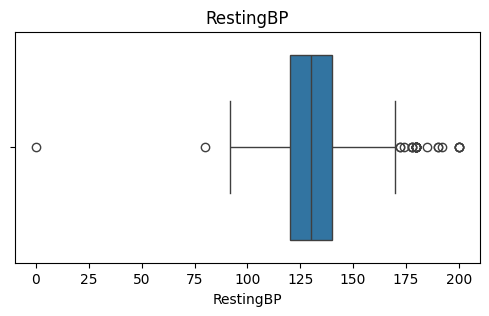

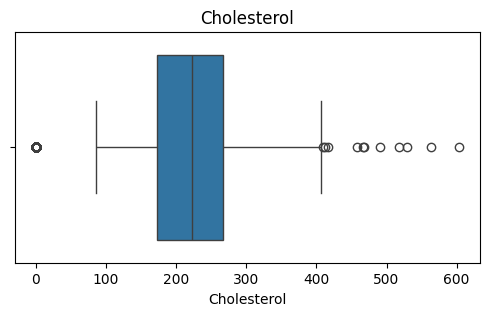

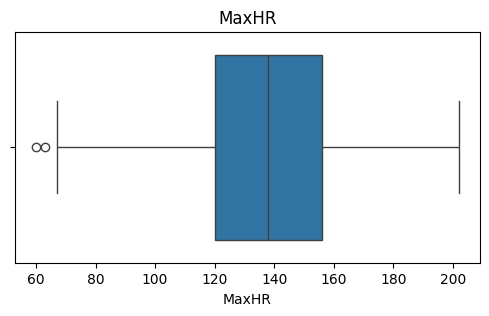

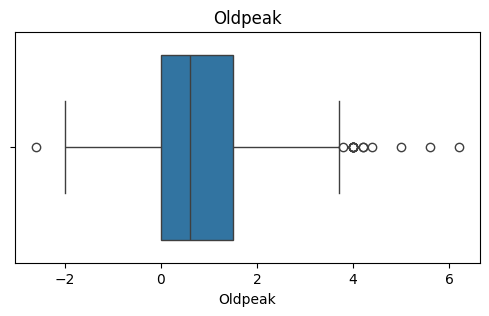

In [51]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Correlation Heatmap

In [52]:
df.corr(numeric_only=True)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


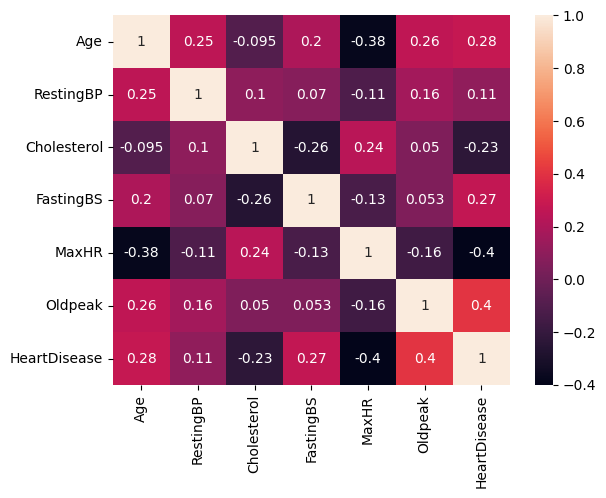

In [53]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## Data Preprocessing 

### Encoding Categorical Variables

In [54]:
df = pd.get_dummies(df, drop_first=True)
print("After Encoding Shape:", df.shape)

After Encoding Shape: (918, 16)


## Feature Engineering

### Split Features & Target

In [55]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

### Train-Test Split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Scaling

In [57]:
scaler = StandardScaler()

X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)

## Machine Learning Models

### LOGISTIC REGRESSION

In [58]:
from sklearn.pipeline import Pipeline

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("LR Accuracy:", lr_acc)

LR Accuracy: 0.8858695652173914


### RANDOM FOREST

In [59]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("RF Accuracy:", rf_acc)

RF Accuracy: 0.8858695652173914


### XGBOOST

In [60]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=15,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.4,
    reg_alpha=0.5,
    reg_lambda=7,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGB Accuracy:", xgb_acc)

XGB Accuracy: 0.8913043478260869


In [61]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [lr_acc, rf_acc, xgb_acc]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.885870
1        Random Forest  0.885870
2              XGBoost  0.891304


In [62]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_acc,
        rf_acc,
        xgb_acc
    ]
})

best_model_name = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

if best_model_name == "Logistic Regression":
    best_model = lr
elif best_model_name == "Random Forest":
    best_model = rf
else:
    best_model = xgb

Best Model: XGBoost


### Classification Report

In [63]:
from sklearn.metrics import classification_report

print("="*60)
print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr.predict(X_test_lr)))

print("="*60)
print("RANDOM FOREST")
print(classification_report(y_test, rf.predict(X_test)))

print("="*60)
print("XGBOOST")
print(classification_report(y_test, xgb.predict(X_test)))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.89      0.80      0.85        82
           1       0.85      0.92      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.88      0.87      0.87        82
           1       0.89      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

XGBOOST
              precision    recall  f1-score   support

           0       0.87      0.89      0.88        82
           1       0.91      0.89      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.8

c:\Users\janaka jayasri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Confusion Matrix

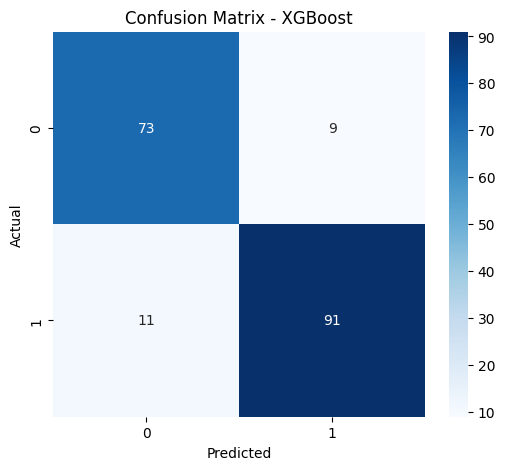

In [64]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - XGBoost")

plt.show()

### ROC Curve

AUC Score: 0.9354375896700143


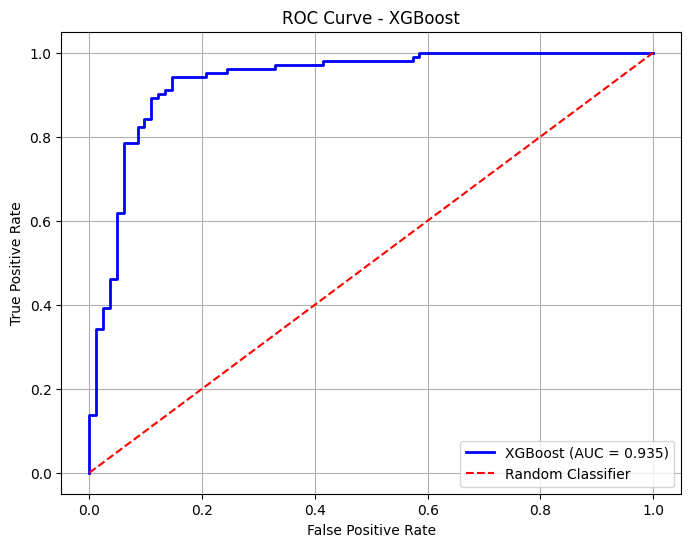

In [65]:
# Predict probabilities

y_prob = xgb.predict_proba(X_test)[:, 1]

# Calculate ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC Score

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    color="blue",
    linewidth=2,
    label=f"XGBoost (AUC = {auc_score:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    color="red",
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

### Compare ROC AUC of All Models

In [66]:
# Logistic Regression

lr_prob = lr.predict_proba(X_test)[:,1]
lr_auc = roc_auc_score(y_test, lr_prob)

# Random Forest

rf_prob = rf.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_prob)

# XGBoost

xgb_prob = xgb.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("Logistic Regression AUC :", lr_auc)
print("Random Forest AUC       :", rf_auc)
print("XGBoost AUC             :", xgb_auc)

Logistic Regression AUC : 0.9296987087517934
Random Forest AUC       : 0.9341224294595887
XGBoost AUC             : 0.9354375896700143


### Plot ROC Curves for All Models

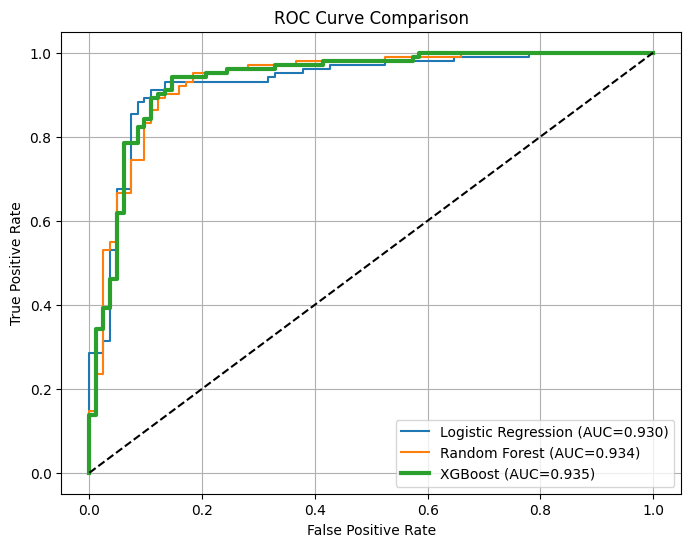

In [67]:
plt.figure(figsize=(8,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC={lr_auc:.3f})"
)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC={rf_auc:.3f})"
)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=3,
    label=f"XGBoost (AUC={xgb_auc:.3f})"
)

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

### Cross Validation

In [68]:
print("="*60)
print("CROSS VALIDATION (5-Fold)")
print("="*60)

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression
lr_cv = cross_val_score(
    lr,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\nLogistic Regression")
print("Fold Accuracies :", lr_cv)
print("Mean Accuracy   :", lr_cv.mean())
print("Std Deviation   :", lr_cv.std())


# Random Forest
rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\nRandom Forest")
print("Fold Accuracies :", rf_cv)
print("Mean Accuracy   :", rf_cv.mean())
print("Std Deviation   :", rf_cv.std())


# XGBoost
xgb_cv = cross_val_score(
    xgb,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\nXGBoost")
print("Fold Accuracies :", xgb_cv)
print("Mean Accuracy   :", xgb_cv.mean())
print("Std Deviation   :", xgb_cv.std())

CROSS VALIDATION (5-Fold)

Logistic Regression
Fold Accuracies : [0.88586957 0.875      0.8423913  0.89071038 0.84153005]
Mean Accuracy   : 0.8671002613447374
Std Deviation   : 0.0211494609238582

Random Forest
Fold Accuracies : [0.91847826 0.86956522 0.84782609 0.86338798 0.84153005]
Mean Accuracy   : 0.8681575196008554
Std Deviation   : 0.02712672550819669

XGBoost
Fold Accuracies : [0.90217391 0.86956522 0.84782609 0.86338798 0.87431694]
Mean Accuracy   : 0.8714540270848182
Std Deviation   : 0.017769726871050107


### Feature Importance

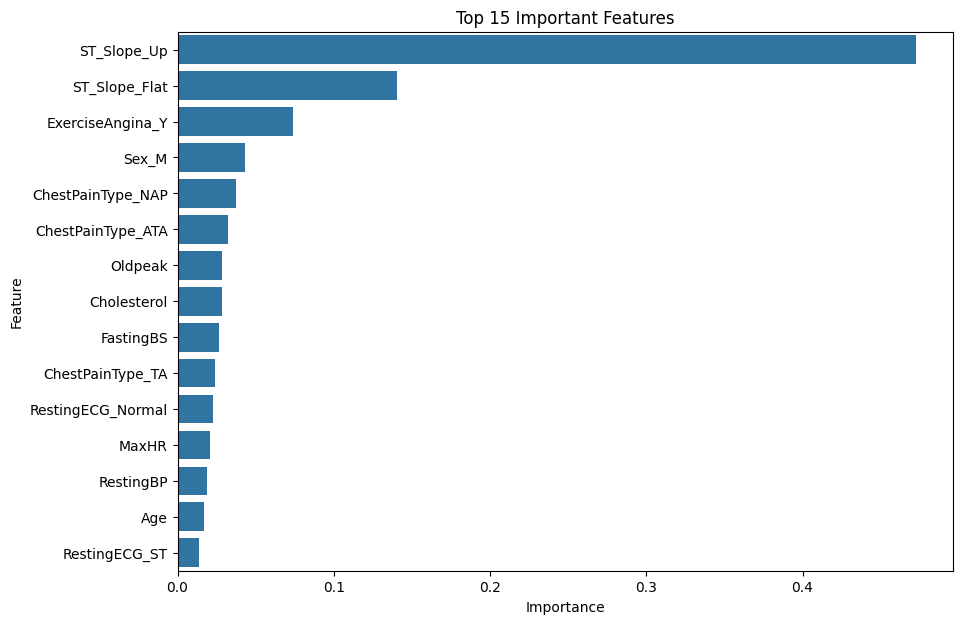

              Feature  Importance
14        ST_Slope_Up    0.472357
13      ST_Slope_Flat    0.140696
12   ExerciseAngina_Y    0.073593
6               Sex_M    0.043481
8   ChestPainType_NAP    0.037465
7   ChestPainType_ATA    0.032460
5             Oldpeak    0.028334
2         Cholesterol    0.028149
3           FastingBS    0.026443
9    ChestPainType_TA    0.023779
10  RestingECG_Normal    0.022898
4               MaxHR    0.020785
1           RestingBP    0.018642
0                 Age    0.017048
11      RestingECG_ST    0.013868


In [69]:
if hasattr(best_model, "feature_importances_"):
    
    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10,7))

    sns.barplot(
        data=importance.head(15),
        x="Importance",
        y="Feature"
    )

    plt.title("Top 15 Important Features")
    plt.show()

    print(importance.head(15))

else:
    print("Feature Importance is not available for Logistic Regression.")

## Save Model

In [70]:
import joblib

joblib.dump(best_model, "heart_disease_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [71]:
loaded_model = joblib.load("heart_disease_model.pkl")

loaded_scaler = joblib.load("scaler.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully
